# Actividad 5 — Desafios en la Limpieza de Datos

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Pipeline:** Fase 1 — Ingenieria de Datos  

---

## Objetivo
Ejecutar todas las decisiones de correccion documentadas en la Actividad 4. Cada transformacion muestra el **antes y despues** con numeros exactos para garantizar la trazabilidad completa del pipeline.

## Transformaciones por fuente
| Fuente | Transformaciones |
|--------|------------------|
| MIDAGRI | Filtro limon, estandarizacion geo, outliers IQR, recorte temporal, agregacion mensual |
| INDECI | Mapeo mes texto→numero, filtro fenomenos, estandarizacion geo, eliminar nulos |
| NASA POWER | Centinelas -999, estandarizacion geo, clipping rangos, imputacion ALLSKY, correccion PRECTOTCORR |
| Agraria.pe | Fechas invalidas, deduplicacion URL, noticias sin titular, conteo mensual |

## Regla de esta actividad
> Cada transformacion muestra **antes y despues** con numeros exactos. No se escalan ni transforman variables para el modelo (eso es Actividad 9).


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata, calendar
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']

def normalizar(t):
    """MAYUSCULAS SIN TILDES, conservando la Ñ."""
    if not isinstance(t, str): return ''
    resultado = []
    for c in t.upper():
        if c == 'Ñ':
            resultado.append('Ñ')
        else:
            c_norm = unicodedata.normalize('NFKD', c).encode('ASCII','ignore').decode('utf-8')
            resultado.append(c_norm)
    return ''.join(resultado).strip()

MESES_ES = {'ENERO':1,'FEBRERO':2,'MARZO':3,'ABRIL':4,'MAYO':5,'JUNIO':6,
            'JULIO':7,'AGOSTO':8,'SETIEMBRE':9,'SEPTIEMBRE':9,'OCTUBRE':10,
            'NOVIEMBRE':11,'DICIEMBRE':12}

def mes_a_num(v):
    try:
        n = int(v)
        return n if 1 <= n <= 12 else None
    except (ValueError, TypeError):
        return MESES_ES.get(str(v).upper().strip(), None)

os.makedirs(OUTPUT['limpieza'], exist_ok=True)
print('Config cargado OK | Raiz:', os.getcwd())
print('Carpeta de salida:', OUTPUT['limpieza'])


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-
Carpeta de salida: pipeline/output/05_limpieza/


---
# 1. Limpieza — MIDAGRI

Transformaciones: filtro limon → estandarizacion geografica → outliers IQR → recorte temporal → agregacion mensual → exportacion.


## Carga del dataset crudo


In [2]:
xl = pd.ExcelFile(SOURCES['midagri'])
dfs = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl.sheet_names]
df_m_raw = pd.concat(dfs, ignore_index=True)
n_raw = len(df_m_raw)
print(f'Dataset crudo MIDAGRI: {df_m_raw.shape}')
print(f'Cultivos unicos: {df_m_raw["dsc_Cultivo"].nunique()}')
print(f'Años disponibles: {sorted(df_m_raw["anho"].unique().tolist())}')


Dataset crudo MIDAGRI: (1596748, 10)
Cultivos unicos: 231
Años disponibles: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 5.1 Paso 1 — Filtro: solo limon


Antes del filtro: 1,596,748 registros (231 cultivos)
Despues del filtro: 40,284 registros (solo LIMON)
Eliminados: 1,556,464 (97.5%)

Nombre exacto del cultivo en el Excel: ['LIMON', 'LIMON DULCE']


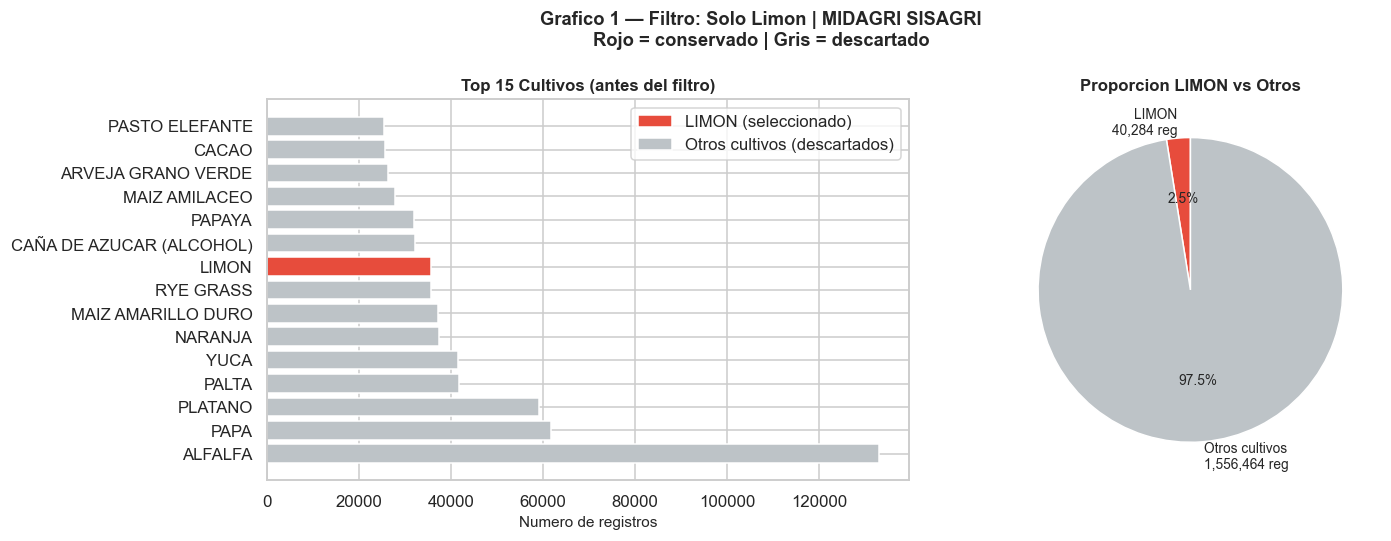

Guardado: pipeline/output/03_eda/act05_midagri_g1_filtro_limon.png


In [3]:
# Filtrar solo LIMON
df_limon = df_m_raw[df_m_raw['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)].copy()
n_limon = len(df_limon)
eliminados_filtro = n_raw - n_limon

print(f'Antes del filtro: {n_raw:,} registros ({df_m_raw["dsc_Cultivo"].nunique()} cultivos)')
print(f'Despues del filtro: {n_limon:,} registros (solo LIMON)')
print(f'Eliminados: {eliminados_filtro:,} ({eliminados_filtro/n_raw*100:.1f}%)')
print()
print('Nombre exacto del cultivo en el Excel:', df_limon['dsc_Cultivo'].unique().tolist())

# Grafico G1: antes/despues filtro limon
top_cultivos = df_m_raw['dsc_Cultivo'].value_counts().head(15)
colors_g1 = ['#e74c3c' if 'LIMON' in str(c).upper() else '#bdc3c7' for c in top_cultivos.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: top cultivos
axes[0].barh(top_cultivos.index, top_cultivos.values, color=colors_g1, edgecolor='white')
axes[0].set_xlabel('Numero de registros', fontsize=10)
axes[0].set_title('Top 15 Cultivos (antes del filtro)', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='#e74c3c', label='LIMON (seleccionado)'),
                         Patch(facecolor='#bdc3c7', label='Otros cultivos (descartados)')])

# Panel derecho: pastel antes/despues
axes[1].pie([n_limon, eliminados_filtro],
            labels=[f'LIMON\n{n_limon:,} reg', f'Otros cultivos\n{eliminados_filtro:,} reg'],
            colors=['#e74c3c','#bdc3c7'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':9})
axes[1].set_title('Proporcion LIMON vs Otros', fontsize=11, fontweight='bold')

plt.suptitle('Grafico 1 — Filtro: Solo Limon | MIDAGRI SISAGRI\n'
             'Rojo = conservado | Gris = descartado',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_midagri_g1_filtro_limon.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La proporcion de registros de limon respecto al total del dataset MIDAGRI. El limon representa una fraccion del total de cultivos registrados.

**Justificacion del filtro:** Se selecciona solo limon porque la cobertura de datos NASA POWER fue descargada especificamente para las provincias productoras de limon. Entrenar el modelo con todos los cultivos requeriria descargar datos NASA para todas las provincias del Peru, lo que no fue factible en el alcance de este proyecto.

**Impacto en el pipeline:** El dataset pasa de todos los cultivos a solo limon, reduciendo significativamente el volumen pero aumentando la especificidad del modelo.


## 5.2 Paso 2 — Estandarizacion geografica


In [4]:
# Estandarizar nombres geograficos a MAYUSCULAS SIN TILDES
cols_geo = ['Dpto', 'Prov', 'Dist']
cols_geo = [c for c in cols_geo if c in df_limon.columns]

# Guardar originales para comparacion
for col in cols_geo:
    df_limon[f'{col}_original'] = df_limon[col].copy()
    df_limon[col] = df_limon[col].apply(normalizar)

# Mostrar variantes corregidas
print('=== ESTANDARIZACION GEOGRAFICA ===')
for col in cols_geo:
    variantes = df_limon.groupby(f'{col}_original')[col].first()
    cambios = variantes[variantes.index != variantes.values]
    if len(cambios) > 0:
        print(f'\n{col} — {len(cambios)} variantes corregidas:')
        for orig, norm in list(cambios.items())[:10]:
            print(f'  "{orig}" → "{norm}"')
    else:
        print(f'\n{col}: Sin variantes (ya estaba normalizado)')

# Limpiar columnas temporales
for col in cols_geo:
    df_limon = df_limon.drop(columns=[f'{col}_original'])

print()
print(f'Departamentos unicos post-normalizacion: {df_limon["Dpto"].nunique()}')
print(f'Provincias unicas post-normalizacion: {df_limon["Prov"].nunique()}')


=== ESTANDARIZACION GEOGRAFICA ===



Dpto: Sin variantes (ya estaba normalizado)

Prov: Sin variantes (ya estaba normalizado)

Dist: Sin variantes (ya estaba normalizado)

Departamentos unicos post-normalizacion: 23
Provincias unicas post-normalizacion: 105


### Interpretacion

**Que muestra:** Las variantes de nombres geograficos que fueron corregidas. Por ejemplo, 'Piura' y 'PIURA' y 'piura' se unifican en 'PIURA'.

**Por que es critico:** La llave de integracion con NASA e INDECI es `(fecha_evento, departamento, provincia)`. Si los nombres no coinciden exactamente, el JOIN producira nulos en lugar de unir los datos correctamente.

**Impacto en el pipeline:** Garantiza que el merge de la Actividad 6 funcione correctamente sin perdida de datos por inconsistencias de nombres.


## 5.3 Paso 3 — Limpieza de outliers (metodo IQR)


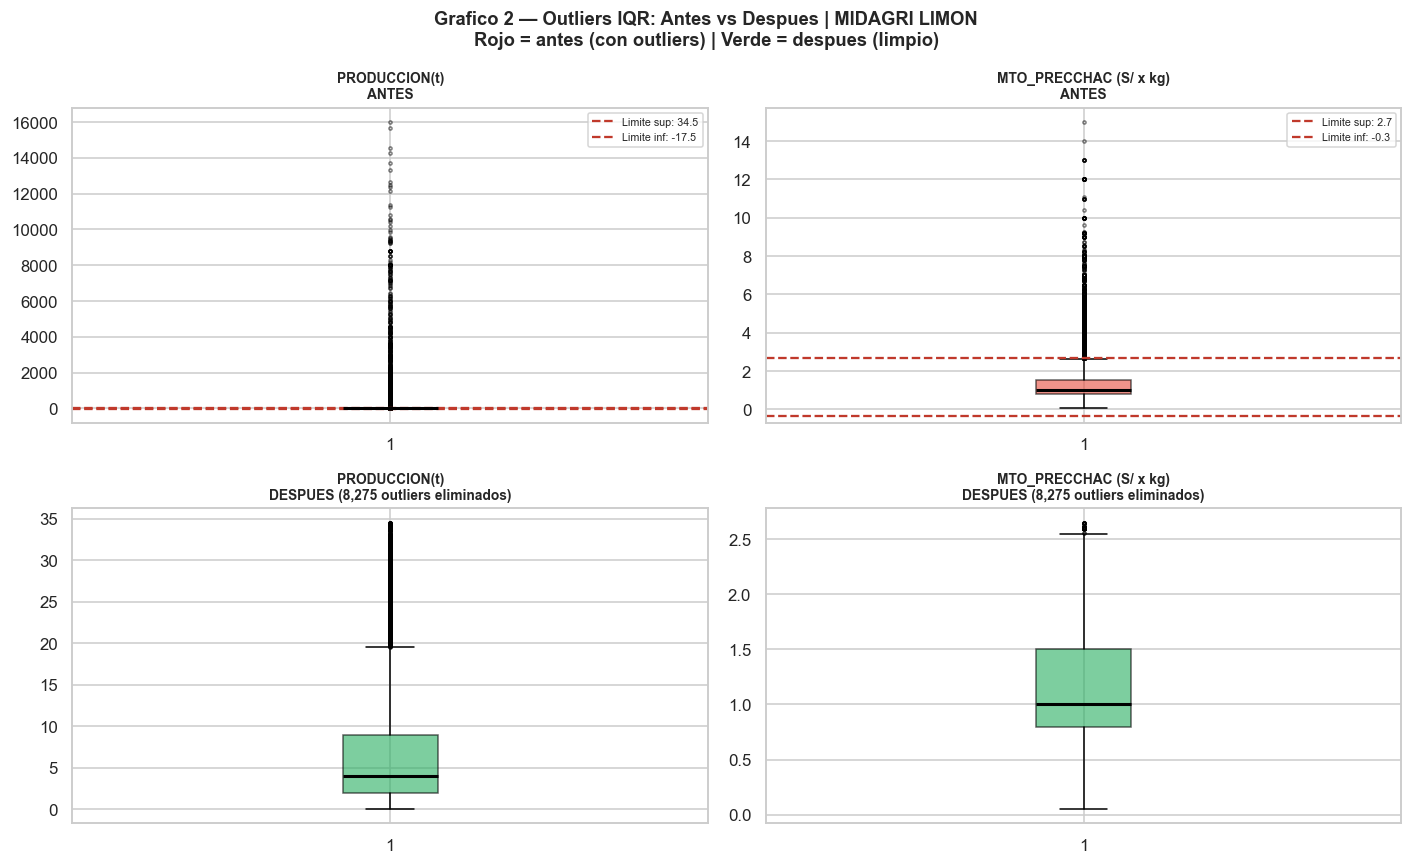

Guardado: pipeline/output/03_eda/act05_midagri_g2_outliers.png
Antes: 40,284 | Despues: 32,009 | Eliminados: 8,275 (20.5%)


In [5]:
cols_num = ['PRODUCCION(t)', 'MTO_PRECCHAC (S/ x kg)']
cols_num = [c for c in cols_num if c in df_limon.columns]

df_antes = df_limon.copy()
n_antes_iqr = len(df_limon)

fig, axes = plt.subplots(2, len(cols_num), figsize=(13, 8))
if len(cols_num) == 1: axes = axes.reshape(2, 1)

resumen_iqr = {}
for j, col in enumerate(cols_num):
    serie = df_limon[col].dropna()
    serie_pos = serie[serie > 0]
    Q1, Q3 = serie_pos.quantile(0.25), serie_pos.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    resumen_iqr[col] = {'lower': lower, 'upper': upper}

    # Boxplot ANTES
    bp1 = axes[0][j].boxplot(serie_pos, patch_artist=True,
                              boxprops=dict(facecolor='#e74c3c', alpha=0.6),
                              medianprops=dict(color='black', linewidth=2),
                              flierprops=dict(marker='o', color='#e74c3c', markersize=2, alpha=0.5))
    axes[0][j].axhline(upper, color='#c0392b', linestyle='--', linewidth=1.5,
                       label=f'Limite sup: {upper:.1f}')
    axes[0][j].axhline(lower, color='#c0392b', linestyle='--', linewidth=1.5,
                       label=f'Limite inf: {lower:.1f}')
    axes[0][j].set_title(f'{col}\nANTES', fontsize=9, fontweight='bold')
    axes[0][j].legend(fontsize=7)

# Aplicar filtro IQR
for col in cols_num:
    lower = resumen_iqr[col]['lower']
    upper = resumen_iqr[col]['upper']
    mask = (df_limon[col].isna()) | ((df_limon[col] >= lower) & (df_limon[col] <= upper))
    df_limon = df_limon[mask]

n_despues_iqr = len(df_limon)
eliminados_iqr = n_antes_iqr - n_despues_iqr

for j, col in enumerate(cols_num):
    serie_clean = df_limon[col].dropna()
    serie_clean = serie_clean[serie_clean > 0]
    bp2 = axes[1][j].boxplot(serie_clean, patch_artist=True,
                              boxprops=dict(facecolor='#27ae60', alpha=0.6),
                              medianprops=dict(color='black', linewidth=2),
                              flierprops=dict(marker='o', color='#27ae60', markersize=2, alpha=0.5))
    axes[1][j].set_title(f'{col}\nDESPUES ({eliminados_iqr:,} outliers eliminados)',
                         fontsize=9, fontweight='bold')

plt.suptitle('Grafico 2 — Outliers IQR: Antes vs Despues | MIDAGRI LIMON\n'
             'Rojo = antes (con outliers) | Verde = despues (limpio)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_midagri_g2_outliers.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print(f'Antes: {n_antes_iqr:,} | Despues: {n_despues_iqr:,} | Eliminados: {eliminados_iqr:,} ({eliminados_iqr/n_antes_iqr*100:.1f}%)')


### Interpretacion

**Que muestra:** La distribucion de produccion y precio antes y despues de aplicar el filtro IQR. Los outliers extremos (puntos rojos) desaparecen en el panel verde.

**Por que IQR:** El metodo IQR (1.5x el rango intercuartilico) es robusto a distribuciones no normales y elimina valores que son estadisticamente imposibles para el cultivo. Un precio de S/. 999/kg o una produccion de 0.001 toneladas son errores de registro.

**Impacto en el modelo:** Los outliers extremos distorsionarian el escalado StandardScaler y harian que el LSTM-Attention aprenda patrones incorrectos. Eliminarlos mejora la calidad del entrenamiento.


## 5.4 Paso 4 — Recorte temporal 2021–2025


In [6]:
n_antes_temporal = len(df_limon)
df_limon = df_limon[(df_limon['anho'] >= 2021) & (df_limon['anho'] <= 2025)].copy()
n_despues_temporal = len(df_limon)
print(f'Antes: {n_antes_temporal:,} | Despues: {n_despues_temporal:,}')
print(f'Años conservados: {sorted(df_limon["anho"].unique().tolist())}')


Antes: 32,009 | Despues: 14,713
Años conservados: [2021, 2022, 2023, 2024, 2025]


### Interpretacion

**Justificacion del recorte:** El rango 2021-2025 es el unico periodo con cobertura simultanea de las 4 fuentes del proyecto. Usar datos anteriores a 2021 sin las variables exogenas (NASA, INDECI, NLP) romperia la consistencia multimodal del dataset maestro.

**Impacto en el pipeline:** Reduce el dataset al periodo de interes del modelo, eliminando datos historicos que no tienen correspondencia en las otras fuentes.

**Impacto en el modelo:** El LSTM-Attention se entrenara con datos del mismo periodo que las variables exogenas, garantizando coherencia temporal en el aprendizaje.


## 5.5 Paso 5 — Agregacion mensual por departamento/provincia


In [7]:
# Construir fecha_evento
df_limon['fecha_evento'] = pd.to_datetime(
    df_limon['anho'].astype(str) + '-' + df_limon['mes'].astype(str).str.zfill(2) + '-01'
).dt.strftime('%Y-%m')

# Renombrar columnas geograficas a estandar del pipeline
df_limon = df_limon.rename(columns={
    'Dpto': 'departamento',
    'Prov': 'provincia',
})

# Agregacion mensual
n_antes_agg = len(df_limon)
df_midagri_clean = (
    df_limon.groupby(['fecha_evento','departamento','provincia'])
    .agg(
        produccion_t=('PRODUCCION(t)', 'sum'),
        cosecha_ha=('COSECHA (ha)', 'sum') if 'COSECHA (ha)' in df_limon.columns else ('PRODUCCION(t)', 'count'),
        precio_chacra_kg=('MTO_PRECCHAC (S/ x kg)', 'mean'),
    )
    .reset_index()
)
n_despues_agg = len(df_midagri_clean)

print(f'Antes de agregar: {n_antes_agg:,} registros (nivel distrito-mensual)')
print(f'Despues de agregar: {n_despues_agg:,} registros (nivel provincia-mensual)')
print(f'Reduccion: {n_antes_agg - n_despues_agg:,} filas')
print()
print(f'Departamentos: {df_midagri_clean["departamento"].nunique()}')
print(f'Provincias: {df_midagri_clean["provincia"].nunique()}')
print(f'Meses: {df_midagri_clean["fecha_evento"].nunique()}')
print(f'Rango: {df_midagri_clean["fecha_evento"].min()} -> {df_midagri_clean["fecha_evento"].max()}')
print()
display(df_midagri_clean.head(5))


Antes de agregar: 14,713 registros (nivel distrito-mensual)
Despues de agregar: 3,942 registros (nivel provincia-mensual)
Reduccion: 10,771 filas

Departamentos: 23
Provincias: 105
Meses: 56
Rango: 2021-01 -> 2025-08



,fecha_evento,departamento,provincia,produccion_t,cosecha_ha,precio_chacra_kg
0,2021-01,AMAZONAS,BAGUA,25.70,0.0,1.960000
1,2021-01,AMAZONAS,CHACHAPOYAS,23.16,0.0,1.500000
2,2021-01,AMAZONAS,LUYA,29.98,0.0,1.339167
3,2021-01,AMAZONAS,UTCUBAMBA,50.80,0.0,0.900000
4,2021-01,ANCASH,CARHUAZ,7.00,0.0,2.400000


### Interpretacion

**Que muestra:** La reduccion de granularidad de nivel distrito-mensual a nivel provincia-mensual. La produccion se suma y el precio se promedia dentro de cada provincia.

**Por que provincia:** La granularidad provincial es la que coincide con los datos de NASA POWER (descargados por provincia) y con los datos de INDECI (reportados por provincia). Usar nivel distrito generaria muchos nulos en el merge con las otras fuentes.

**Impacto en el modelo:** La granularidad provincial garantiza que el dataset maestro tenga series temporales completas y coherentes para el entrenamiento del LSTM-Attention.


## 5.6 Grafico 3 — Distribucion de produccion post-limpieza


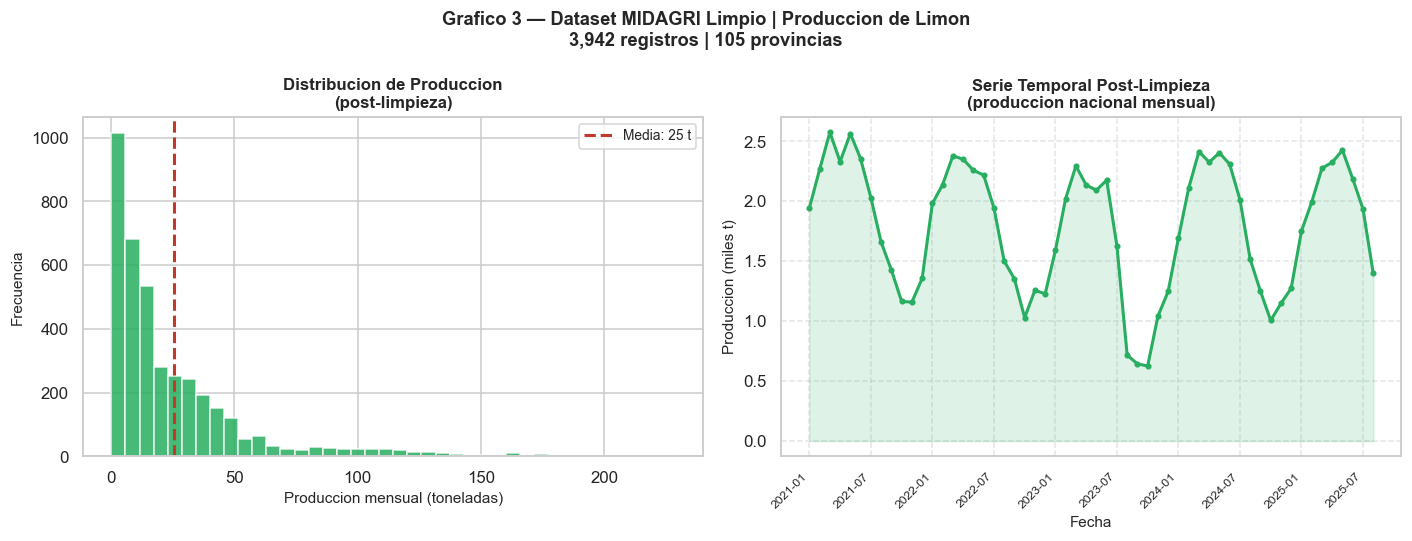

Guardado: pipeline/output/03_eda/act05_midagri_g3_produccion_limpia.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma produccion
axes[0].hist(df_midagri_clean['produccion_t'], bins=40,
             color='#27ae60', edgecolor='white', alpha=0.85)
axes[0].axvline(df_midagri_clean['produccion_t'].mean(), color='#c0392b',
                linestyle='--', linewidth=2,
                label=f'Media: {df_midagri_clean["produccion_t"].mean():.0f} t')
axes[0].set_xlabel('Produccion mensual (toneladas)', fontsize=10)
axes[0].set_ylabel('Frecuencia', fontsize=10)
axes[0].set_title('Distribucion de Produccion\n(post-limpieza)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Serie temporal produccion nacional
serie = df_midagri_clean.groupby('fecha_evento')['produccion_t'].sum()
axes[1].plot(range(len(serie)), serie.values/1e3, color='#27ae60',
             linewidth=2, marker='o', markersize=3)
axes[1].fill_between(range(len(serie)), serie.values/1e3, alpha=0.15, color='#27ae60')
axes[1].set_xticks(range(0, len(serie), 6))
axes[1].set_xticklabels(serie.index[::6], rotation=45, ha='right', fontsize=8)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('Produccion (miles t)', fontsize=10)
axes[1].set_title('Serie Temporal Post-Limpieza\n(produccion nacional mensual)', fontsize=11, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Grafico 3 — Dataset MIDAGRI Limpio | Produccion de Limon\n'
             f'{len(df_midagri_clean):,} registros | {df_midagri_clean["provincia"].nunique()} provincias',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_midagri_g3_produccion_limpia.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La distribucion y serie temporal de la produccion de limon despues de todas las transformaciones de limpieza. La distribucion debe ser mas simetrica que antes.

**Validacion:** La serie temporal debe mostrar el patron estacional esperado (picos y valles regulares). Si la serie es plana o tiene saltos bruscos, puede indicar que la limpieza fue demasiado agresiva.

**Impacto en el modelo:** Un dataset limpio con distribucion razonable permite que el StandardScaler de la Actividad 9 funcione correctamente y que el LSTM-Attention aprenda patrones reales.


## 5.7 Exportacion MIDAGRI limpio


In [9]:
out_midagri = OUTPUT['limpieza'] + 'midagri_limon_clean.csv'
df_midagri_clean.to_csv(out_midagri, index=False, encoding='utf-8-sig')
print(f'Exportado: {out_midagri}')
print(f'Shape final: {df_midagri_clean.shape}')
print(f'Columnas: {df_midagri_clean.columns.tolist()}')
print()
print('Resumen de transformaciones MIDAGRI:')
print(f'  1. Filtro limon:        {n_raw:,} → {n_limon:,} ({n_raw-n_limon:,} eliminados)')
print(f'  2. Estandarizacion geo: nombres normalizados')
print(f'  3. Outliers IQR:        {n_antes_iqr:,} → {n_despues_iqr:,} ({eliminados_iqr:,} eliminados)')
print(f'  4. Recorte temporal:    {n_antes_temporal:,} → {n_despues_temporal:,}')
print(f'  5. Agregacion mensual:  {n_antes_agg:,} → {n_despues_agg:,} (nivel provincia)')
print(f'  RESULTADO FINAL:        {len(df_midagri_clean):,} registros')


Exportado: pipeline/output/05_limpieza/midagri_limon_clean.csv
Shape final: (3942, 6)
Columnas: ['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg']

Resumen de transformaciones MIDAGRI:
  1. Filtro limon:        1,596,748 → 40,284 (1,556,464 eliminados)
  2. Estandarizacion geo: nombres normalizados
  3. Outliers IQR:        40,284 → 32,009 (8,275 eliminados)
  4. Recorte temporal:    32,009 → 14,713
  5. Agregacion mensual:  14,713 → 3,942 (nivel provincia)
  RESULTADO FINAL:        3,942 registros


---
# 2. Limpieza — INDECI

Transformaciones: mapeo mes texto→numero → filtro fenomenos → estandarizacion geografica → eliminar nulos → exportacion.


## Carga del dataset crudo


In [10]:
dfs_shp = []
for d in sorted(glob.glob(SOURCES['indeci_shapefiles'] + 'E_*/')):
    shp = glob.glob(d + '*.shp')
    if shp:
        gdf = gpd.read_file(shp[0])
        df_tmp = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))
        df_tmp.columns = [str(c).lower() for c in df_tmp.columns]
        dfs_shp.append(df_tmp)
df_indeci_raw = pd.concat(dfs_shp, ignore_index=True)
n_indeci_raw = len(df_indeci_raw)
print(f'Dataset crudo INDECI: {df_indeci_raw.shape}')
print(f'Fenomenos unicos: {df_indeci_raw["fenomeno"].nunique()}')


Dataset crudo INDECI: (25025, 79)
Fenomenos unicos: 57


## 5.8 Paso 1 — Mapeo columna mes: texto → numero


Valores originales en columna mes:
mes
ABRIL        2011
AGOSTO       1473
DICIEMBRE     618
ENERO        3767
FEBRERO      4030
JULIO        1140
JUNIO        1129
MARZO        3690
MAYO         1113
NOVIEMBRE    2333
OCTUBRE      1961
SETIEMBRE    1760

Registros con fecha_evento valida: 25,025
Registros sin fecha_evento (mes no reconocido): 0


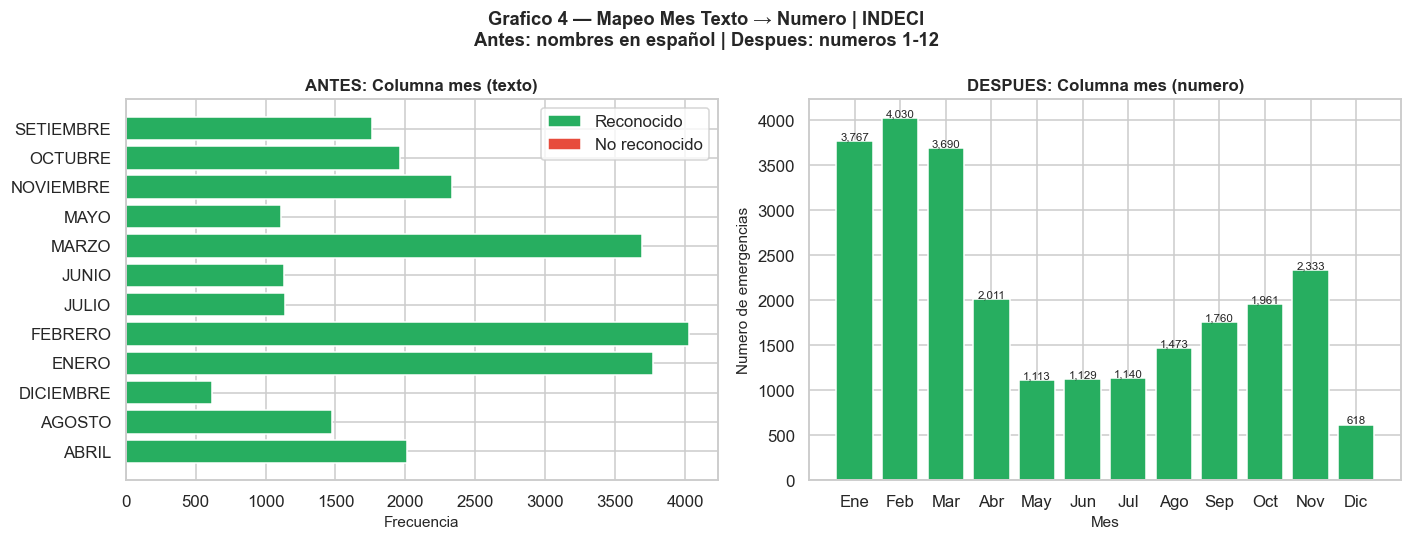

Guardado: pipeline/output/03_eda/act05_indeci_g4_mes_mapeo.png


In [11]:
df_indeci = df_indeci_raw.copy()

# Mostrar valores originales
print('Valores originales en columna mes:')
print(df_indeci['mes'].value_counts().sort_index().to_string())
print()

# Aplicar mapeo
df_indeci['mes_num'] = df_indeci['mes'].apply(mes_a_num)
df_indeci['anho_int'] = pd.to_numeric(df_indeci['anho'], errors='coerce')

# Construir fecha_evento
df_indeci['fecha_evento'] = pd.to_datetime(
    df_indeci['anho_int'].astype(str) + '-' +
    df_indeci['mes_num'].fillna(1).astype(int).astype(str).str.zfill(2) + '-01',
    errors='coerce'
).dt.strftime('%Y-%m')
df_indeci.loc[df_indeci['mes_num'].isna(), 'fecha_evento'] = None

n_sin_fecha = df_indeci['fecha_evento'].isna().sum()
print(f'Registros con fecha_evento valida: {(~df_indeci["fecha_evento"].isna()).sum():,}')
print(f'Registros sin fecha_evento (mes no reconocido): {n_sin_fecha}')

# Grafico G4: antes/despues mapeo mes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Antes: valores texto
vals_antes = df_indeci['mes'].value_counts().sort_index()
colors_antes = ['#27ae60' if str(v).upper() in MESES_ES else '#e74c3c'
                for v in vals_antes.index]
axes[0].barh(vals_antes.index.astype(str), vals_antes.values,
             color=colors_antes, edgecolor='white')
axes[0].set_xlabel('Frecuencia', fontsize=10)
axes[0].set_title('ANTES: Columna mes (texto)', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='#27ae60', label='Reconocido'),
                         Patch(facecolor='#e74c3c', label='No reconocido')])

# Despues: valores numericos
vals_despues = df_indeci['mes_num'].value_counts().sort_index().dropna()
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
etiquetas = [meses_nombres[int(m)-1] if pd.notna(m) and 1<=int(m)<=12 else str(m)
             for m in vals_despues.index]
axes[1].bar(etiquetas, vals_despues.values, color='#27ae60', edgecolor='white')
for i, val in enumerate(vals_despues.values):
    axes[1].text(i, val+10, f'{int(val):,}', ha='center', fontsize=7.5)
axes[1].set_xlabel('Mes', fontsize=10)
axes[1].set_ylabel('Numero de emergencias', fontsize=10)
axes[1].set_title('DESPUES: Columna mes (numero)', fontsize=11, fontweight='bold')

plt.suptitle('Grafico 4 — Mapeo Mes Texto → Numero | INDECI\n'
             'Antes: nombres en español | Despues: numeros 1-12',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_indeci_g4_mes_mapeo.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La conversion de la columna mes de texto en español a numero. El panel izquierdo muestra los valores originales (ENERO, FEBRERO...) y el panel derecho muestra los valores convertidos (1, 2...).

**Por que es necesario:** La columna mes en los shapefiles INDECI viene en formato texto porque es el formato nativo del sistema SINPAD. Para construir la columna `fecha_evento` (YYYY-MM) necesaria para el JOIN con las otras fuentes, se requiere el numero del mes.

**Impacto en el pipeline:** Sin esta conversion, la serie temporal de emergencias no puede construirse y el merge con MIDAGRI y NASA fallaria.


## 5.9 Paso 2 — Filtro de fenomenos relevantes para agricultura


Antes: 25,025 | Despues: 13,487 | Eliminados: 11,538 (46.1%)

Fenomenos conservados:
fenomeno_norm
LLUVIAS INTENSAS    7490
VIENTOS FUERTES     2495
DESLIZAMIENTO       1777
HELADAS             1215
INUNDACION           480
FRIAJE                30


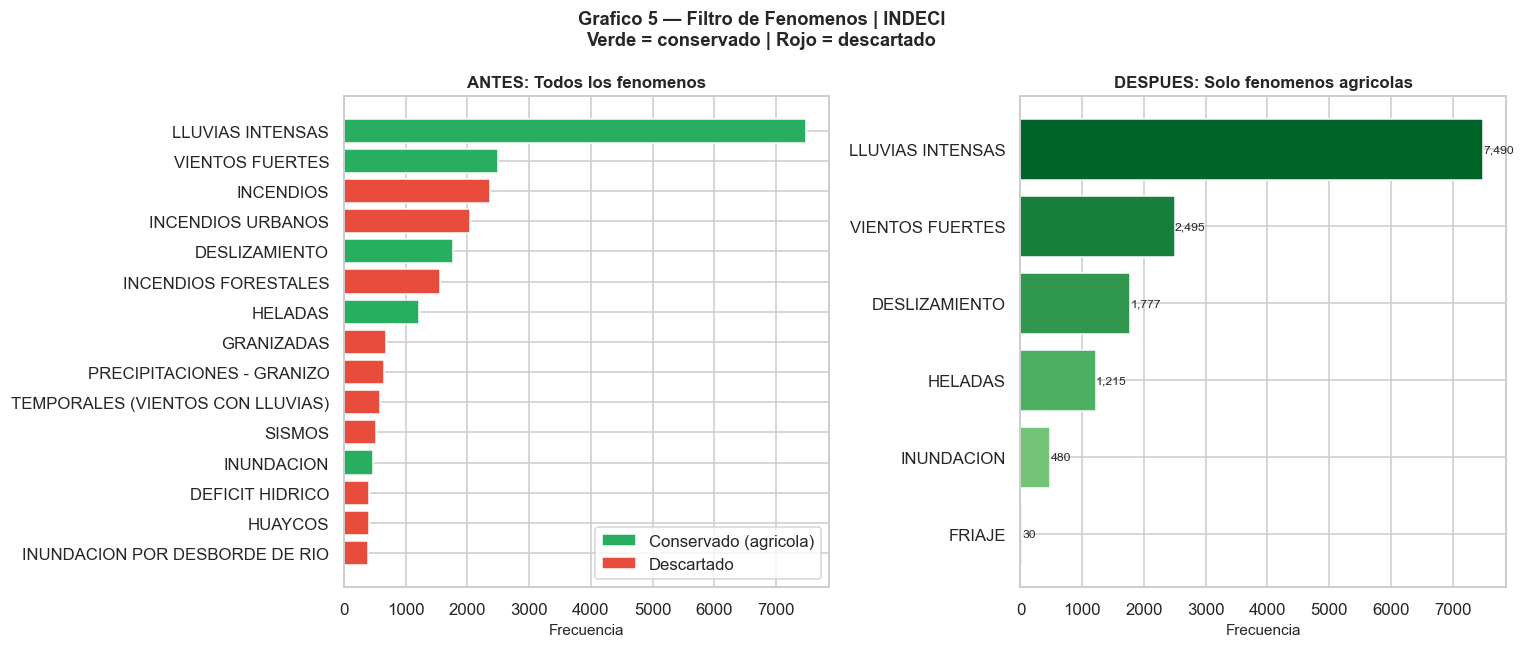

Guardado: pipeline/output/03_eda/act05_indeci_g5_fenomenos.png


In [12]:
FENOMENOS_VALIDOS = [normalizar(f) for f in CONFIG['fenomenos_indeci']]
df_indeci['fenomeno_norm'] = df_indeci['fenomeno'].apply(normalizar)

n_antes_fen = len(df_indeci)
df_indeci_agro = df_indeci[df_indeci['fenomeno_norm'].isin(FENOMENOS_VALIDOS)].copy()
n_despues_fen = len(df_indeci_agro)
eliminados_fen = n_antes_fen - n_despues_fen

print(f'Antes: {n_antes_fen:,} | Despues: {n_despues_fen:,} | Eliminados: {eliminados_fen:,} ({eliminados_fen/n_antes_fen*100:.1f}%)')
print()
print('Fenomenos conservados:')
print(df_indeci_agro['fenomeno_norm'].value_counts().to_string())

# Grafico G5: antes/despues filtro fenomenos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Antes: todos los fenomenos
top_fen_antes = df_indeci['fenomeno_norm'].value_counts().head(15).sort_values(ascending=True)
colors_fen = ['#27ae60' if f in FENOMENOS_VALIDOS else '#e74c3c' for f in top_fen_antes.index]
axes[0].barh(top_fen_antes.index, top_fen_antes.values, color=colors_fen, edgecolor='white')
axes[0].set_xlabel('Frecuencia', fontsize=10)
axes[0].set_title('ANTES: Todos los fenomenos', fontsize=11, fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='#27ae60', label='Conservado (agricola)'),
                         Patch(facecolor='#e74c3c', label='Descartado')])

# Despues: solo fenomenos agricolas
fen_despues = df_indeci_agro['fenomeno_norm'].value_counts().sort_values(ascending=True)
colors_d = plt.cm.Greens(np.linspace(0.4, 0.9, len(fen_despues)))
axes[1].barh(fen_despues.index, fen_despues.values, color=colors_d, edgecolor='white')
for i, val in enumerate(fen_despues.values):
    axes[1].text(val+5, i, f'{int(val):,}', va='center', fontsize=8)
axes[1].set_xlabel('Frecuencia', fontsize=10)
axes[1].set_title('DESPUES: Solo fenomenos agricolas', fontsize=11, fontweight='bold')

plt.suptitle('Grafico 5 — Filtro de Fenomenos | INDECI\n'
             'Verde = conservado | Rojo = descartado',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_indeci_g5_fenomenos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** Los fenomenos que se conservan (verde) y los que se descartan (rojo). Solo se conservan los fenomenos hidrometeorologicos con impacto directo en la agricultura.

**Justificacion:** Los fenomenos descartados (accidentes de transito, incendios urbanos, derrumbes de edificios) no tienen relacion causal con la produccion agricola. Incluirlos generaria ruido en la variable `num_emergencias`.

**Impacto en el modelo:** Un conteo de emergencias mas especifico (solo fenomenos agricolas) tiene mayor poder predictivo que un conteo general de todos los tipos de emergencias.


## 5.10 Paso 3 — Estandarizacion geografica y exportacion


Eliminados por nulos en columnas clave: 0


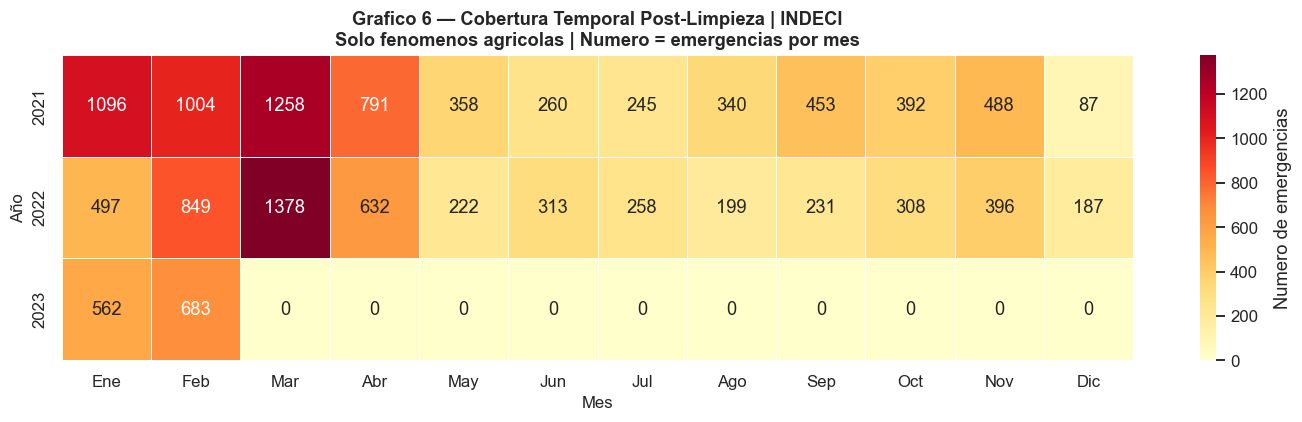

Guardado: pipeline/output/03_eda/act05_indeci_g6_cobertura.png
Exportado: pipeline/output/05_limpieza/indeci_eventos_clean.csv
Shape final: (13487, 11)

Resumen de transformaciones INDECI:
  1. Mapeo mes texto→numero: 25,025 registros procesados
  2. Filtro fenomenos:       25,025 → 13,487 (11,538 eliminados)
  3. Estandarizacion geo:    nombres normalizados
  4. Eliminar nulos clave:   13,487 → 13,487
  RESULTADO FINAL:           13,487 registros


In [13]:
# Estandarizar nombres geograficos
df_indeci_agro['departamento'] = df_indeci_agro['departamen'].apply(normalizar)
df_indeci_agro['provincia']    = df_indeci_agro['provincia'].apply(normalizar)

# Eliminar nulos en columnas clave
n_antes_nulos = len(df_indeci_agro)
df_indeci_agro = df_indeci_agro.dropna(subset=['fecha_evento','departamento','fenomeno_norm'])
n_despues_nulos = len(df_indeci_agro)
print(f'Eliminados por nulos en columnas clave: {n_antes_nulos - n_despues_nulos}')

# Seleccionar columnas relevantes para el pipeline
cols_output = ['fecha_evento','departamento','provincia','fenomeno_norm',
               'anho_int','mes_num']
# Agregar columnas de impacto si existen
for col_impacto in ['safecta','sdamni','sfalle','sareaculti','sareacul_1']:
    if col_impacto in df_indeci_agro.columns:
        cols_output.append(col_impacto)
cols_output = [c for c in cols_output if c in df_indeci_agro.columns]

df_indeci_clean = df_indeci_agro[cols_output].copy()

# Renombrar columnas de impacto a nombres descriptivos
rename_map = {
    'fenomeno_norm': 'fenomeno',
    'anho_int': 'anho',
    'mes_num': 'mes',
    'safecta': 'personas_afectadas',
    'sdamni': 'personas_damnificadas',
    'sfalle': 'personas_fallecidas',
    'sareaculti': 'has_cultivo_afectadas',
    'sareacul_1': 'has_cultivo_perdidas',
}
df_indeci_clean = df_indeci_clean.rename(columns={k:v for k,v in rename_map.items() if k in df_indeci_clean.columns})

# Grafico G6: cobertura temporal post-limpieza
cobertura = df_indeci_clean.groupby(['anho','mes']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13, 4))
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
cobertura.columns = [meses_nombres[int(c)-1] if pd.notna(c) and 1<=int(c)<=12 else str(c)
                     for c in cobertura.columns]
sns.heatmap(cobertura, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Numero de emergencias'})
ax.set_title('Grafico 6 — Cobertura Temporal Post-Limpieza | INDECI\n'
             'Solo fenomenos agricolas | Numero = emergencias por mes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Año', fontsize=11)
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_indeci_g6_cobertura.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)

# Exportar
out_indeci = OUTPUT['limpieza'] + 'indeci_eventos_clean.csv'
df_indeci_clean.to_csv(out_indeci, index=False, encoding='utf-8-sig')
print(f'Exportado: {out_indeci}')
print(f'Shape final: {df_indeci_clean.shape}')
print()
print('Resumen de transformaciones INDECI:')
print(f'  1. Mapeo mes texto→numero: {n_indeci_raw:,} registros procesados')
print(f'  2. Filtro fenomenos:       {n_antes_fen:,} → {n_despues_fen:,} ({eliminados_fen:,} eliminados)')
print(f'  3. Estandarizacion geo:    nombres normalizados')
print(f'  4. Eliminar nulos clave:   {n_antes_nulos:,} → {n_despues_nulos:,}')
print(f'  RESULTADO FINAL:           {len(df_indeci_clean):,} registros')


### Interpretacion

**Que muestra:** La cobertura temporal del dataset INDECI limpio. Cada celda muestra el numero de emergencias agricolas registradas en ese mes y año.

**Validacion:** Los meses de temporada de lluvias (dic-mar) deben tener mas emergencias que los meses secos. Si el patron es inverso, puede indicar un problema en el filtro.

**Impacto en el pipeline:** El dataset limpio tiene la granularidad correcta para el merge con MIDAGRI y NASA en la Actividad 6.


---
# 3. Limpieza — NASA POWER

Transformaciones: centinelas -999 → estandarizacion geo → clipping rangos → imputacion ALLSKY → correccion PRECTOTCORR mm/dia→mm/mes → exportacion.


## Carga del dataset crudo


In [14]:
df_nasa_raw = pd.read_csv(OUTPUT['lectura'] + 'nasa_long_raw.csv', low_memory=False)
VARS_CLIMA = [c for c in df_nasa_raw.columns if c not in ['DEPARTAMENTO','PROVINCIA','YEAR','MES']]
RANGOS = {'T2M':[-10.0,50.0],'T2M_MAX':[-5.0,55.0],'T2M_MIN':[-20.0,40.0],
          'PRECTOTCORR':[0.0,50.0],'RH2M':[0.0,100.0],'QV2M':[0.0,30.0],
          'ALLSKY_SFC_SW_DWN':[0.0,35.0],'WS2M':[0.0,20.0]}
n_nasa_raw = len(df_nasa_raw)
print(f'Dataset crudo NASA: {df_nasa_raw.shape}')
print(f'Variables climaticas: {VARS_CLIMA}')
print(f'Nulos por variable:')
print(df_nasa_raw[VARS_CLIMA].isnull().sum().to_string())


Dataset crudo NASA: (6120, 12)
Variables climaticas: ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M']
Nulos por variable:
ALLSKY_SFC_SW_DWN    102
PRECTOTCORR            0
QV2M                   0
RH2M                   0
T2M                    0
T2M_MAX                0
T2M_MIN                0
WS2M                   0


## 5.11 Paso 1 — Reemplazar centinelas -999 por NaN


In [15]:
df_nasa = df_nasa_raw.copy()

# Contar centinelas antes
centinelas_antes = {var: (df_nasa[var] == -999.0).sum() for var in VARS_CLIMA}
total_centinelas = sum(centinelas_antes.values())

# Reemplazar
for var in VARS_CLIMA:
    df_nasa[var] = df_nasa[var].replace(-999.0, np.nan)

centinelas_despues = {var: (df_nasa[var] == -999.0).sum() for var in VARS_CLIMA}
print(f'Centinelas -999 encontrados: {total_centinelas}')
if total_centinelas > 0:
    for var, n in centinelas_antes.items():
        if n > 0:
            print(f'  {var}: {n} centinelas convertidos a NaN')
else:
    print('  OK: No se encontraron centinelas residuales.')
    print('  Los valores -999 fueron correctamente convertidos en la Actividad 2.')


Centinelas -999 encontrados: 0
  OK: No se encontraron centinelas residuales.
  Los valores -999 fueron correctamente convertidos en la Actividad 2.


### Interpretacion

**Que muestra:** La verificacion de que no quedan valores centinela -999 en el dataset. Este paso es una medida de seguridad aunque la Actividad 4 ya confirmo 0 centinelas.

**Por que es importante:** Si quedaran valores -999 sin convertir, el StandardScaler de la Actividad 9 los trataria como valores extremamente negativos, distorsionando el escalado de toda la variable.

**Impacto en el pipeline:** Garantiza que todos los valores faltantes esten correctamente representados como NaN antes de la imputacion.


## 5.12 Paso 2 — Estandarizacion geografica


In [16]:
df_nasa['DEPARTAMENTO'] = df_nasa['DEPARTAMENTO'].apply(normalizar)
df_nasa['PROVINCIA']    = df_nasa['PROVINCIA'].apply(normalizar)

print(f'Departamentos unicos: {df_nasa["DEPARTAMENTO"].nunique()}')
print(f'Provincias unicas: {df_nasa["PROVINCIA"].nunique()}')
print()
print('Muestra de nombres normalizados:')
print(df_nasa[['DEPARTAMENTO','PROVINCIA']].drop_duplicates().head(10).to_string())


Departamentos unicos: 23
Provincias unicas: 102

Muestra de nombres normalizados:
    DEPARTAMENTO    PROVINCIA
0       AMAZONAS        BAGUA
60      AMAZONAS  CHACHAPOYAS
120     AMAZONAS         LUYA
180     AMAZONAS    UTCUBAMBA
240       ANCASH        CASMA
300       ANCASH      HUARMEY
360       ANCASH      HUAYLAS
420       ANCASH        SANTA
480     APURIMAC      ABANCAY
540     APURIMAC  ANDAHUAYLAS


## 5.13 Paso 3 — Clipping de rangos fisicos


In [17]:
violaciones_antes = {}
for var in VARS_CLIMA:
    if var in RANGOS:
        rmin, rmax = RANGOS[var]
        data = df_nasa[var].dropna()
        violaciones_antes[var] = ((data < rmin) | (data > rmax)).sum()
        df_nasa[var] = df_nasa[var].clip(lower=rmin, upper=rmax)

total_violaciones = sum(violaciones_antes.values())
print(f'Total violaciones de rango fisico: {total_violaciones}')
if total_violaciones > 0:
    for var, n in violaciones_antes.items():
        if n > 0:
            print(f'  {var}: {n} valores clipeados a [{RANGOS[var][0]}, {RANGOS[var][1]}]')
else:
    print('  OK: Ninguna variable tiene valores fuera de rangos fisicos.')


Total violaciones de rango fisico: 0
  OK: Ninguna variable tiene valores fuera de rangos fisicos.


## 5.14 Paso 4 — Imputacion de nulos en ALLSKY_SFC_SW_DWN


Nulos en ALLSKY_SFC_SW_DWN antes: 102
Nulos en ALLSKY_SFC_SW_DWN despues: 0
Valores imputados: 102


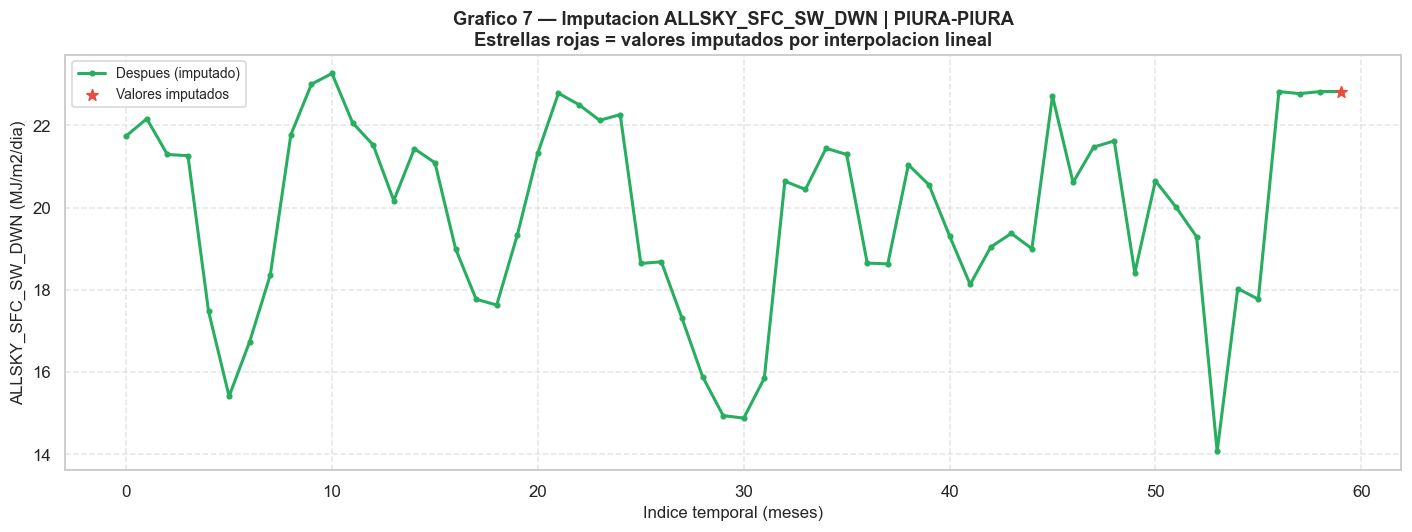

Guardado: pipeline/output/03_eda/act05_nasa_g7_imputacion.png


In [18]:
# Verificar nulos antes
nulos_allsky_antes = df_nasa['ALLSKY_SFC_SW_DWN'].isnull().sum()
print(f'Nulos en ALLSKY_SFC_SW_DWN antes: {nulos_allsky_antes}')

# Guardar serie antes para el grafico
piura_mask = ((df_nasa['DEPARTAMENTO']=='PIURA') & (df_nasa['PROVINCIA']=='PIURA'))
allsky_antes = df_nasa[piura_mask].sort_values(['YEAR','MES'])['ALLSKY_SFC_SW_DWN'].copy()

# Imputar con interpolacion lineal por provincia
df_nasa = df_nasa.sort_values(['DEPARTAMENTO','PROVINCIA','YEAR','MES'])
df_nasa['ALLSKY_SFC_SW_DWN'] = (
    df_nasa.groupby(['DEPARTAMENTO','PROVINCIA'])['ALLSKY_SFC_SW_DWN']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

nulos_allsky_despues = df_nasa['ALLSKY_SFC_SW_DWN'].isnull().sum()
print(f'Nulos en ALLSKY_SFC_SW_DWN despues: {nulos_allsky_despues}')
print(f'Valores imputados: {nulos_allsky_antes - nulos_allsky_despues}')

# Grafico G7: antes/despues imputacion ALLSKY para Piura
allsky_despues = df_nasa[piura_mask].sort_values(['YEAR','MES'])['ALLSKY_SFC_SW_DWN'].copy()
x = range(len(allsky_antes))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, allsky_despues.values, color='#27ae60', linewidth=2,
        marker='o', markersize=3, label='Despues (imputado)', zorder=3)
# Marcar los puntos imputados
mask_imputados = allsky_antes.isna().values
if mask_imputados.any():
    ax.scatter([i for i, m in enumerate(mask_imputados) if m],
               [allsky_despues.values[i] for i, m in enumerate(mask_imputados) if m],
               color='#e74c3c', s=60, zorder=4, label='Valores imputados', marker='*')
ax.set_xlabel('Indice temporal (meses)', fontsize=11)
ax.set_ylabel('ALLSKY_SFC_SW_DWN (MJ/m2/dia)', fontsize=11)
ax.set_title('Grafico 7 — Imputacion ALLSKY_SFC_SW_DWN | PIURA-PIURA\n'
             'Estrellas rojas = valores imputados por interpolacion lineal',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_nasa_g7_imputacion.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La serie temporal de radiacion solar para Piura antes y despues de la imputacion. Las estrellas rojas marcan los valores que fueron imputados por interpolacion lineal.

**Por que interpolacion lineal:** Los nulos corresponden a meses futuros (sep-dic 2025) para los que NASA aun no tiene datos. La interpolacion lineal es apropiada porque la radiacion solar tiene un patron estacional suave y predecible.

**Impacto en el modelo:** Sin imputacion, el merge de la Actividad 6 generaria nulos en la variable ALLSKY para los meses futuros, lo que podria excluir esos meses del entrenamiento.


## 5.15 Paso 5 — Correccion critica: PRECTOTCORR de mm/dia a mm/mes

> **Esta es la correccion mas importante del pipeline NASA.** Los archivos fuente tienen PRECTOTCORR en mm/dia (promedio diario del mes). Para el modelo necesitamos el total mensual en mm.


PRECTOTCORR PIURA-PIURA Marzo 2021 (mm/dia): [0.91]
Dias en Marzo: 31
Total mensual esperado (mm/mes): 28.21 mm

PRECTOTCORR PIURA-PIURA Marzo 2021 (mm/mes CORREGIDO): [28.21]


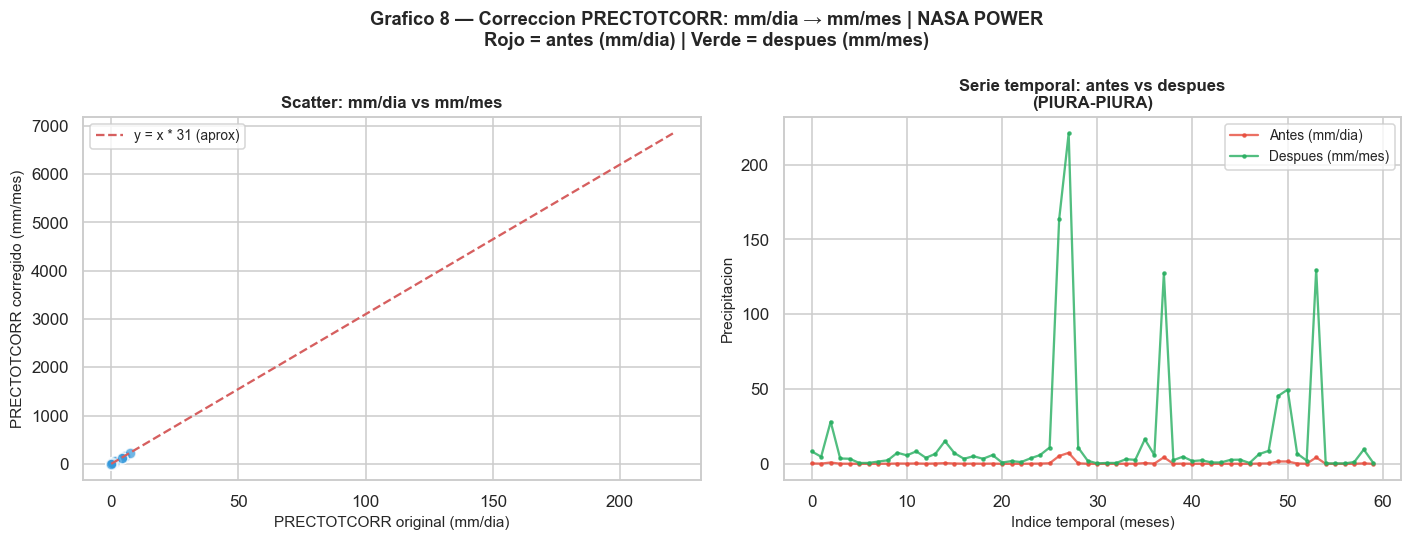

Guardado: pipeline/output/03_eda/act05_nasa_g8_prectotcorr.png


In [19]:
# Verificar el problema: PRECTOTCORR actual es mm/dia
ejemplo = df_nasa[(df_nasa['DEPARTAMENTO']=='PIURA') &
                  (df_nasa['PROVINCIA']=='PIURA') &
                  (df_nasa['YEAR']==2021) &
                  (df_nasa['MES']==3)]['PRECTOTCORR'].values
print(f'PRECTOTCORR PIURA-PIURA Marzo 2021 (mm/dia): {ejemplo}')
print(f'Dias en Marzo: 31')
print(f'Total mensual esperado (mm/mes): {ejemplo[0]*31:.2f} mm' if len(ejemplo)>0 else 'Sin datos')
print()

# Guardar valores antes para el grafico
precip_antes = df_nasa[piura_mask].sort_values(['YEAR','MES'])['PRECTOTCORR'].copy()

# Aplicar la correccion: multiplicar por dias del mes
def dias_del_mes(row):
    try:
        return calendar.monthrange(int(row['YEAR']), int(row['MES']))[1]
    except:
        return 30

df_nasa['dias_mes'] = df_nasa.apply(dias_del_mes, axis=1)
df_nasa['PRECTOTCORR'] = df_nasa['PRECTOTCORR'] * df_nasa['dias_mes']
df_nasa = df_nasa.drop(columns=['dias_mes'])

# Verificar la correccion
ejemplo_corr = df_nasa[(df_nasa['DEPARTAMENTO']=='PIURA') &
                       (df_nasa['PROVINCIA']=='PIURA') &
                       (df_nasa['YEAR']==2021) &
                       (df_nasa['MES']==3)]['PRECTOTCORR'].values
print(f'PRECTOTCORR PIURA-PIURA Marzo 2021 (mm/mes CORREGIDO): {ejemplo_corr}')

# Grafico G8: scatter antes vs despues
precip_despues = df_nasa[piura_mask].sort_values(['YEAR','MES'])['PRECTOTCORR'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter antes vs despues
axes[0].scatter(precip_antes.values, precip_despues.values,
                alpha=0.7, color='#3498db', edgecolors='white', s=50)
max_val = max(precip_despues.max(), precip_antes.max())
axes[0].plot([0, max_val], [0, max_val*31], 'r--', linewidth=1.5,
             label='y = x * 31 (aprox)')
axes[0].set_xlabel('PRECTOTCORR original (mm/dia)', fontsize=10)
axes[0].set_ylabel('PRECTOTCORR corregido (mm/mes)', fontsize=10)
axes[0].set_title('Scatter: mm/dia vs mm/mes', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Series temporales antes vs despues
x = range(len(precip_antes))
axes[1].plot(x, precip_antes.values, color='#e74c3c', linewidth=1.5,
             marker='o', markersize=2, label='Antes (mm/dia)', alpha=0.8)
axes[1].plot(x, precip_despues.values, color='#27ae60', linewidth=1.5,
             marker='o', markersize=2, label='Despues (mm/mes)', alpha=0.8)
axes[1].set_xlabel('Indice temporal (meses)', fontsize=10)
axes[1].set_ylabel('Precipitacion', fontsize=10)
axes[1].set_title('Serie temporal: antes vs despues\n(PIURA-PIURA)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Grafico 8 — Correccion PRECTOTCORR: mm/dia → mm/mes | NASA POWER\n'
             'Rojo = antes (mm/dia) | Verde = despues (mm/mes)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_nasa_g8_prectotcorr.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La diferencia entre el valor original de PRECTOTCORR (mm/dia) y el valor corregido (mm/mes). El scatter muestra que la relacion es lineal (multiplicacion por los dias del mes).

**Por que es critica esta correccion:** La precipitacion en mm/dia es el promedio diario del mes, no el total mensual. Para el modelo agricola necesitamos el total mensual porque es lo que determina si hubo sequia o inundacion en ese mes.

**Impacto en el modelo:** Sin esta correccion, el modelo aprenderia que en marzo llueve 0.91 mm (promedio diario) cuando en realidad llovio 28.21 mm en total. Esto distorsionaria completamente la relacion entre precipitacion y produccion.


## 5.16 Paso 6 — Construir fecha_evento y exportar


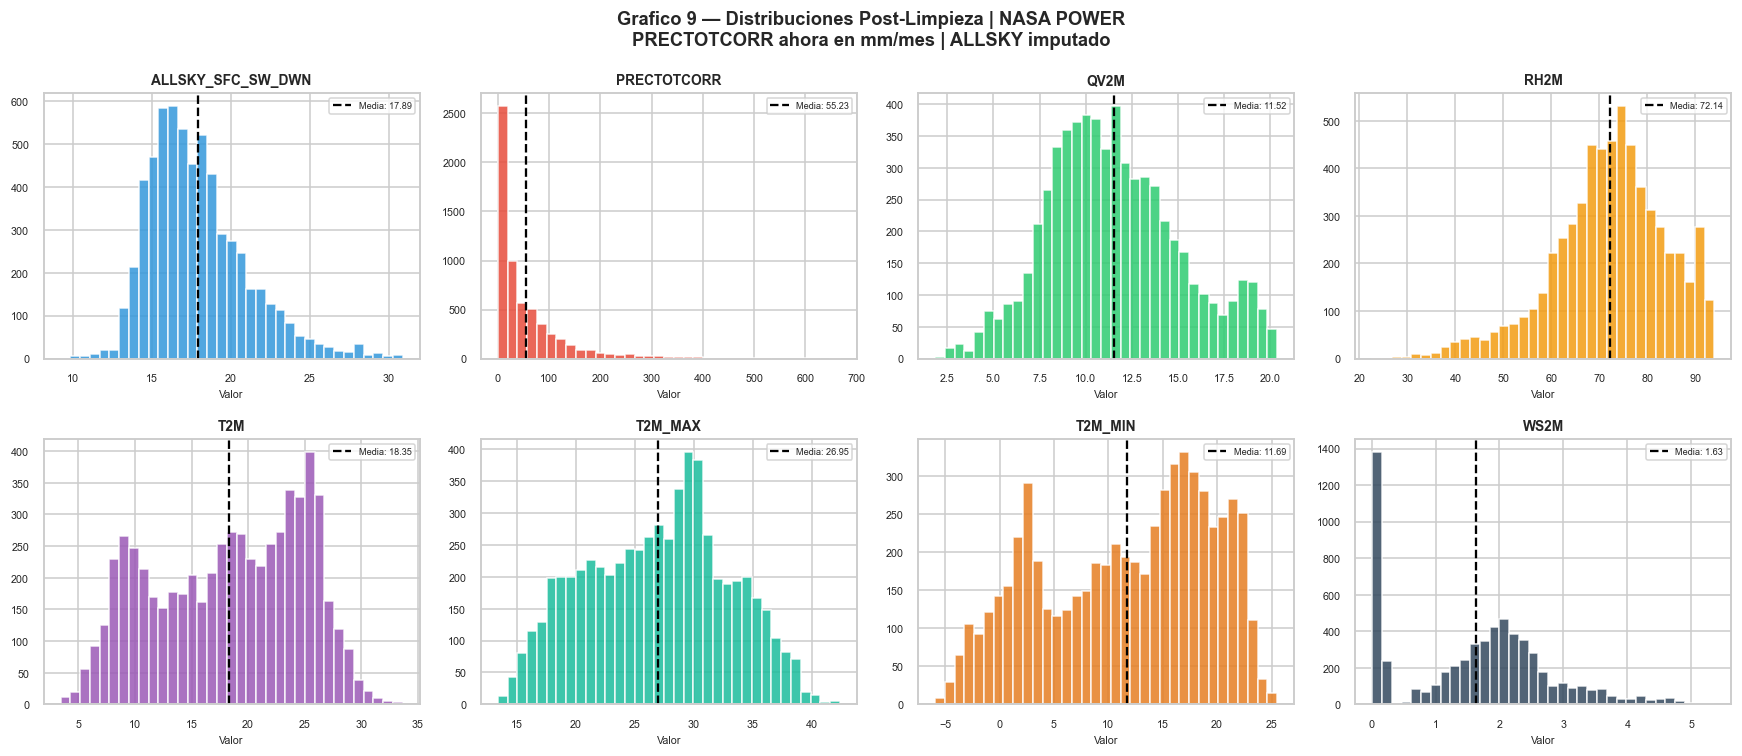

Guardado: pipeline/output/03_eda/act05_nasa_g9_distribuciones.png
Exportado: pipeline/output/05_limpieza/nasa_long_clean.csv
Shape final: (6120, 13)
Nulos residuales: 0

Resumen de transformaciones NASA:
  1. Centinelas -999:     0 encontrados
  2. Estandarizacion geo: nombres normalizados
  3. Clipping rangos:     0 valores clipeados
  4. Imputacion ALLSKY:   102 nulos → 0
  5. PRECTOTCORR:         mm/dia → mm/mes (x dias del mes)
  RESULTADO FINAL:        6,120 registros


In [20]:
# Construir fecha_evento
df_nasa['fecha_evento'] = pd.to_datetime(
    df_nasa['YEAR'].astype(str) + '-' + df_nasa['MES'].astype(str).str.zfill(2) + '-01'
).dt.strftime('%Y-%m')

# Renombrar columnas a minusculas para consistencia
df_nasa_clean = df_nasa.rename(columns={
    'DEPARTAMENTO': 'departamento',
    'PROVINCIA': 'provincia',
    'YEAR': 'anho',
    'MES': 'mes'
})

# Grafico G9: distribuciones post-limpieza
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colores = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']
for i, (var, color) in enumerate(zip(VARS_CLIMA, colores)):
    col_lower = var.lower() if var.lower() in df_nasa_clean.columns else var
    col_use = col_lower if col_lower in df_nasa_clean.columns else var
    if col_use not in df_nasa_clean.columns: continue
    data = df_nasa_clean[col_use].dropna()
    axes[i].hist(data, bins=35, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Media: {data.mean():.2f}')
    axes[i].set_title(var, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=7)
    axes[i].legend(fontsize=6)
    axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Grafico 9 — Distribuciones Post-Limpieza | NASA POWER\n'
             'PRECTOTCORR ahora en mm/mes | ALLSKY imputado',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_nasa_g9_distribuciones.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)

# Exportar
out_nasa = OUTPUT['limpieza'] + 'nasa_long_clean.csv'
df_nasa_clean.to_csv(out_nasa, index=False, encoding='utf-8-sig')
print(f'Exportado: {out_nasa}')
print(f'Shape final: {df_nasa_clean.shape}')
print(f'Nulos residuales: {df_nasa_clean[VARS_CLIMA].isnull().sum().sum()}')
print()
print('Resumen de transformaciones NASA:')
print(f'  1. Centinelas -999:     {total_centinelas} encontrados')
print(f'  2. Estandarizacion geo: nombres normalizados')
print(f'  3. Clipping rangos:     {total_violaciones} valores clipeados')
print(f'  4. Imputacion ALLSKY:   {nulos_allsky_antes} nulos → {nulos_allsky_despues}')
print(f'  5. PRECTOTCORR:         mm/dia → mm/mes (x dias del mes)')
print(f'  RESULTADO FINAL:        {len(df_nasa_clean):,} registros')


### Interpretacion

**Que muestra:** Las distribuciones de las 8 variables climaticas despues de todas las transformaciones. PRECTOTCORR ahora muestra valores en mm/mes (mas altos que antes) y ALLSKY no tiene nulos.

**Validacion:** Las distribuciones deben ser fisicamente razonables para el Peru. Temperaturas entre -10 y 50°C, precipitacion entre 0 y 1500 mm/mes, etc.

**Impacto en el pipeline:** El dataset NASA limpio esta listo para el merge con MIDAGRI e INDECI en la Actividad 6.


---
# 4. Limpieza — Agraria.pe

Transformaciones: fechas invalidas → deduplicacion URL → noticias sin titular → normalizacion fechas → conteo mensual → exportacion.


## Carga del dataset crudo


In [21]:
df_agr_raw = pd.read_csv(OUTPUT['lectura'] + 'agraria_raw.csv',
                         on_bad_lines='skip', low_memory=False)
n_agr_raw = len(df_agr_raw)
df_agr_raw['fecha_dt'] = pd.to_datetime(df_agr_raw['fecha'], errors='coerce')
df_agr_raw['anio'] = df_agr_raw['fecha_dt'].dt.year
print(f'Dataset crudo Agraria: {df_agr_raw.shape}')
print(f'Rango: {df_agr_raw["fecha_dt"].min()} -> {df_agr_raw["fecha_dt"].max()}')


Dataset crudo Agraria: (528, 9)
Rango: 2021-01-04 00:00:00 -> 2025-12-22 00:00:00


## 5.17 Paso 1 — Eliminar fechas invalidas y fuera de rango


In [22]:
df_agr = df_agr_raw.copy()

# Fechas no parseables
n_antes_fecha = len(df_agr)
df_agr = df_agr.dropna(subset=['fecha_dt'])
n_sin_fecha = n_antes_fecha - len(df_agr)

# Fechas fuera del rango 2021-2025
n_antes_rango = len(df_agr)
df_agr = df_agr[(df_agr['anio'] >= 2021) & (df_agr['anio'] <= 2025)]
n_fuera_rango = n_antes_rango - len(df_agr)

print(f'Eliminados por fecha invalida: {n_sin_fecha}')
print(f'Eliminados por fuera de rango 2021-2025: {n_fuera_rango}')
print(f'Restantes: {len(df_agr):,}')
print()
print('Distribucion por año post-filtro:')
print(df_agr['anio'].value_counts().sort_index().to_string())


Eliminados por fecha invalida: 0
Eliminados por fuera de rango 2021-2025: 0
Restantes: 528

Distribucion por año post-filtro:
anio
2021     44
2022    133
2023    118
2024    108
2025    125


## 5.18 Paso 2 — Deduplicacion por URL


Duplicados por URL eliminados: 0
Restantes: 528


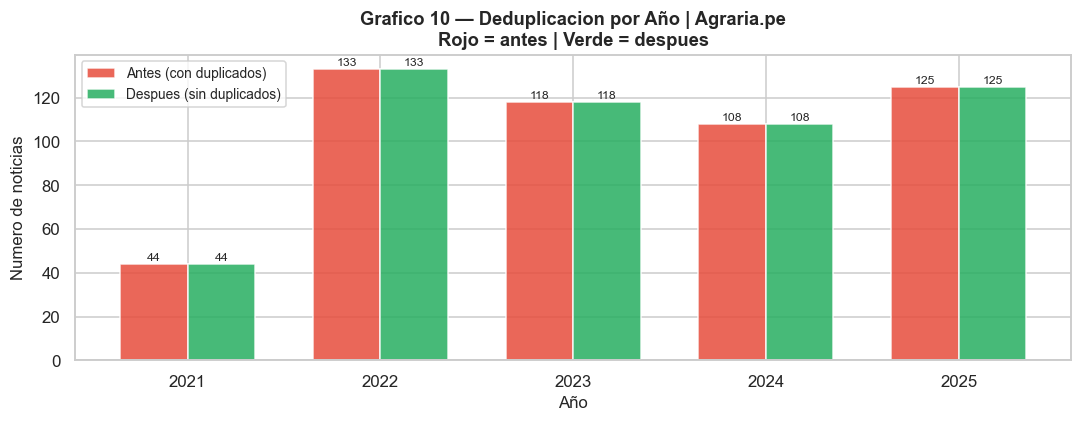

Guardado: pipeline/output/03_eda/act05_agraria_g10_dedup.png


In [23]:
n_antes_dup = len(df_agr)
if 'url' in df_agr.columns:
    df_agr = df_agr.drop_duplicates(subset=['url'], keep='first')
    n_duplicados = n_antes_dup - len(df_agr)
    print(f'Duplicados por URL eliminados: {n_duplicados}')
else:
    # Deduplicar por titular + fecha
    df_agr = df_agr.drop_duplicates(subset=['titular','fecha'], keep='first')
    n_duplicados = n_antes_dup - len(df_agr)
    print(f'Duplicados por titular+fecha eliminados: {n_duplicados}')

print(f'Restantes: {len(df_agr):,}')

# Grafico G10: antes/despues deduplicacion por año
por_anio_antes = df_agr_raw.dropna(subset=['fecha_dt'])
por_anio_antes = por_anio_antes[(por_anio_antes['anio']>=2021)&(por_anio_antes['anio']<=2025)]
por_anio_antes = por_anio_antes['anio'].value_counts().sort_index()
por_anio_despues = df_agr['anio'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(por_anio_antes))
width = 0.35
bars1 = ax.bar(x - width/2, por_anio_antes.values, width, color='#e74c3c',
               edgecolor='white', label='Antes (con duplicados)', alpha=0.85)
bars2 = ax.bar(x + width/2, [por_anio_despues.get(a, 0) for a in por_anio_antes.index],
               width, color='#27ae60', edgecolor='white', label='Despues (sin duplicados)', alpha=0.85)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(por_anio_antes.index.astype(str))
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Numero de noticias', fontsize=11)
ax.set_title('Grafico 10 — Deduplicacion por Año | Agraria.pe\n'
             'Rojo = antes | Verde = despues',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_agraria_g10_dedup.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** El numero de noticias por año antes y despues de la deduplicacion. Si las barras son iguales, no habia duplicados. Si la barra verde es menor, se eliminaron noticias duplicadas.

**Por que deduplicar:** El scraper puede haber visitado la misma noticia dos veces si aparecia en multiples categorias de Agraria.pe. Contar la misma noticia dos veces infla artificialmente el `n_noticias` mensual.

**Impacto en el modelo:** Un conteo mensual de noticias sin duplicados es una señal mas limpia y confiable para el LSTM-Attention.


## 5.19 Paso 3 — Eliminar noticias sin titular util


In [24]:
n_antes_titular = len(df_agr)
df_agr['len_titular'] = df_agr['titular'].fillna('').apply(lambda x: len(str(x).split()))
df_agr = df_agr[df_agr['len_titular'] >= 3].copy()
n_sin_titular = n_antes_titular - len(df_agr)
print(f'Noticias sin titular util (<3 palabras) eliminadas: {n_sin_titular}')
print(f'Restantes: {len(df_agr):,}')


Noticias sin titular util (<3 palabras) eliminadas: 0
Restantes: 528


## 5.20 Paso 4 — Construir fecha_evento y exportar


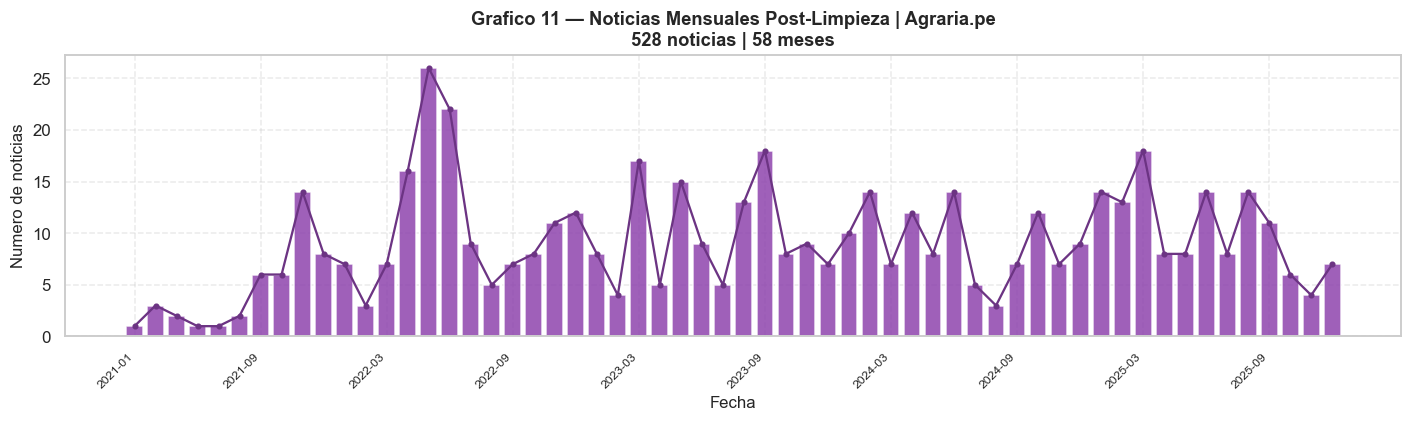

Guardado: pipeline/output/03_eda/act05_agraria_g11_serie.png
Exportado: pipeline/output/05_limpieza/agraria_noticias_clean.csv | Shape: (528, 7)
Exportado: pipeline/output/05_limpieza/agraria_mensual.csv | Shape: (58, 2)

Resumen de transformaciones Agraria.pe:
  1. Fechas invalidas:    0 eliminadas
  2. Fuera de rango:      0 eliminadas
  3. Deduplicacion URL:   0 eliminadas
  4. Sin titular util:    0 eliminadas
  RESULTADO FINAL:        528 noticias
  Conteo mensual:         58 meses


In [25]:
# Construir fecha_evento
df_agr['fecha_evento'] = df_agr['fecha_dt'].dt.strftime('%Y-%m')

# Dataset completo con texto (para Fase 2 — BETO)
cols_texto = ['fecha_evento','fecha','titular','cuerpo_completo','fuente','url','anio']
cols_texto = [c for c in cols_texto if c in df_agr.columns]
df_agr_clean = df_agr[cols_texto].copy()

# Conteo mensual (para Fase 1 — variable n_noticias)
df_agr_mensual = df_agr.groupby('fecha_evento').size().reset_index(name='n_noticias')
df_agr_mensual = df_agr_mensual.sort_values('fecha_evento')

# Grafico G11: serie temporal noticias limpias
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(df_agr_mensual)), df_agr_mensual['n_noticias'],
       color='#8e44ad', edgecolor='white', alpha=0.85)
ax.plot(range(len(df_agr_mensual)), df_agr_mensual['n_noticias'],
        color='#6c3483', linewidth=1.5, marker='o', markersize=3)
ax.set_xticks(range(0, len(df_agr_mensual), 6))
ax.set_xticklabels(df_agr_mensual['fecha_evento'].iloc[::6], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Numero de noticias', fontsize=11)
ax.set_title('Grafico 11 — Noticias Mensuales Post-Limpieza | Agraria.pe\n'
             f'{len(df_agr_clean):,} noticias | {len(df_agr_mensual)} meses',
             fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_agraria_g11_serie.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)

# Exportar
out_agr_clean = OUTPUT['limpieza'] + 'agraria_noticias_clean.csv'
out_agr_mensual = OUTPUT['limpieza'] + 'agraria_mensual.csv'
df_agr_clean.to_csv(out_agr_clean, index=False, encoding='utf-8-sig')
df_agr_mensual.to_csv(out_agr_mensual, index=False, encoding='utf-8-sig')
print(f'Exportado: {out_agr_clean} | Shape: {df_agr_clean.shape}')
print(f'Exportado: {out_agr_mensual} | Shape: {df_agr_mensual.shape}')
print()
print('Resumen de transformaciones Agraria.pe:')
print(f'  1. Fechas invalidas:    {n_sin_fecha} eliminadas')
print(f'  2. Fuera de rango:      {n_fuera_rango} eliminadas')
print(f'  3. Deduplicacion URL:   {n_duplicados} eliminadas')
print(f'  4. Sin titular util:    {n_sin_titular} eliminadas')
print(f'  RESULTADO FINAL:        {len(df_agr_clean):,} noticias')
print(f'  Conteo mensual:         {len(df_agr_mensual)} meses')


### Interpretacion

**Que muestra:** La serie temporal de noticias mensuales despues de la limpieza. La distribucion debe ser relativamente uniforme entre meses.

**Dos archivos de salida:** Se exportan dos archivos porque tienen propositos diferentes. El archivo completo con texto se usara en la Fase 2 (BETO para analisis de sentimiento). El conteo mensual se usara en la Fase 1 como variable exogena `n_noticias`.

**Impacto en el modelo:** Un conteo mensual limpio y sin duplicados es una señal mas confiable para el LSTM-Attention que el conteo crudo.


---
# 5. Resumen Consolidado de la Limpieza


## Grafico 12 — Tabla resumen: registros antes vs despues


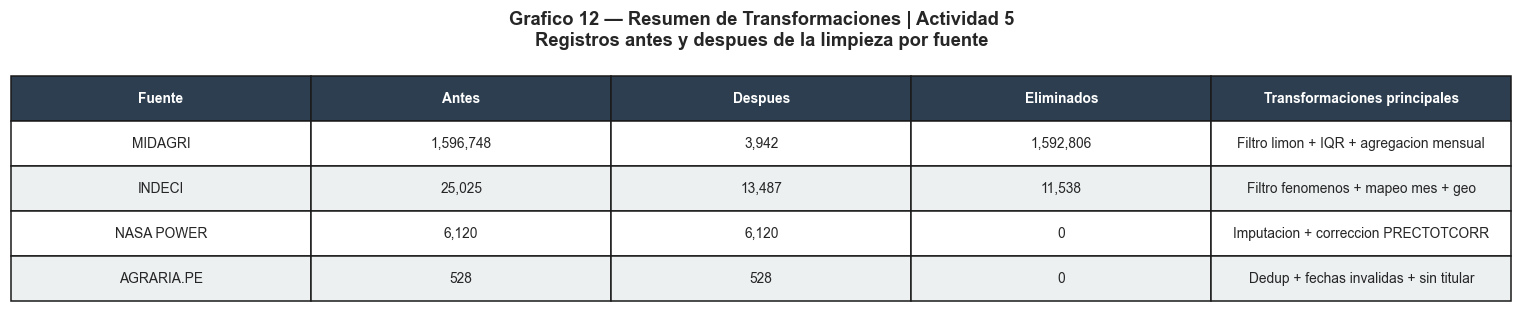

Guardado: pipeline/output/03_eda/act05_resumen_transformaciones.png



,Fuente,Antes,Despues,Eliminados,Transformaciones principales
0,MIDAGRI,"1,596,748","3,942","1,592,806",Filtro limon + IQR + agregacion mensual
1,INDECI,"25,025","13,487","11,538",Filtro fenomenos + mapeo mes + geo
2,NASA POWER,"6,120","6,120",0,Imputacion + correccion PRECTOTCORR
3,AGRARIA.PE,528,528,0,Dedup + fechas invalidas + sin titular


In [26]:
# Tabla resumen de todas las transformaciones
resumen = [
    ['MIDAGRI', f'{n_raw:,}', f'{len(df_midagri_clean):,}',
     f'{n_raw-len(df_midagri_clean):,}', 'Filtro limon + IQR + agregacion mensual'],
    ['INDECI', f'{n_indeci_raw:,}', f'{len(df_indeci_clean):,}',
     f'{n_indeci_raw-len(df_indeci_clean):,}', 'Filtro fenomenos + mapeo mes + geo'],
    ['NASA POWER', f'{n_nasa_raw:,}', f'{len(df_nasa_clean):,}',
     '0', 'Imputacion + correccion PRECTOTCORR'],
    ['AGRARIA.PE', f'{n_agr_raw:,}', f'{len(df_agr_clean):,}',
     f'{n_agr_raw-len(df_agr_clean):,}', 'Dedup + fechas invalidas + sin titular'],
]
df_resumen = pd.DataFrame(resumen,
    columns=['Fuente','Antes','Despues','Eliminados','Transformaciones principales'])

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
tabla = ax.table(
    cellText=df_resumen.values,
    colLabels=df_resumen.columns,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    else:
        cell.set_facecolor('white')
ax.set_title('Grafico 12 — Resumen de Transformaciones | Actividad 5\n'
             'Registros antes y despues de la limpieza por fuente',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_resumen_transformaciones.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print()
display(df_resumen)


## Grafico 13 — Comparativa de nulos antes vs despues


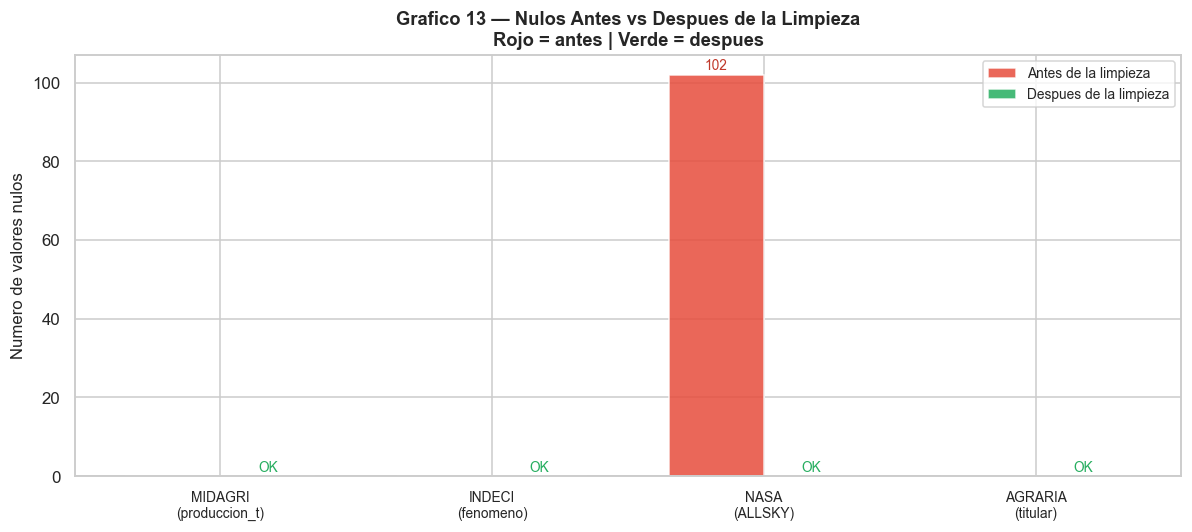

Guardado: pipeline/output/03_eda/act05_resumen_nulos.png


In [27]:
# Comparar nulos antes y despues en cada dataset
nulos_comparativa = {
    'MIDAGRI\n(produccion_t)': [
        df_m_raw['PRODUCCION(t)'].isnull().sum(),
        df_midagri_clean['produccion_t'].isnull().sum()
    ],
    'INDECI\n(fenomeno)': [
        df_indeci_raw['fenomeno'].isnull().sum(),
        df_indeci_clean['fenomeno'].isnull().sum()
    ],
    'NASA\n(ALLSKY)': [
        df_nasa_raw['ALLSKY_SFC_SW_DWN'].isnull().sum(),
        df_nasa_clean['ALLSKY_SFC_SW_DWN'].isnull().sum() if 'ALLSKY_SFC_SW_DWN' in df_nasa_clean.columns
        else df_nasa_clean['allsky_sfc_sw_dwn'].isnull().sum() if 'allsky_sfc_sw_dwn' in df_nasa_clean.columns
        else 0
    ],
    'AGRARIA\n(titular)': [
        df_agr_raw['titular'].isnull().sum(),
        df_agr_clean['titular'].isnull().sum()
    ],
}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(nulos_comparativa))
width = 0.35
antes_vals = [v[0] for v in nulos_comparativa.values()]
despues_vals = [v[1] for v in nulos_comparativa.values()]

bars1 = ax.bar(x - width/2, antes_vals, width, color='#e74c3c',
               edgecolor='white', label='Antes de la limpieza', alpha=0.85)
bars2 = ax.bar(x + width/2, despues_vals, width, color='#27ae60',
               edgecolor='white', label='Despues de la limpieza', alpha=0.85)

for bar, val in zip(bars1, antes_vals):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(val), ha='center', va='bottom', fontsize=9, color='#c0392b')
for bar, val in zip(bars2, despues_vals):
    label = str(val) if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            label, ha='center', va='bottom', fontsize=9, color=color)

ax.set_xticks(x)
ax.set_xticklabels(list(nulos_comparativa.keys()), fontsize=9)
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 13 — Nulos Antes vs Despues de la Limpieza\n'
             'Rojo = antes | Verde = despues',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
g = OUTPUT['eda'] + 'act05_resumen_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La reduccion de valores nulos en cada fuente despues de la limpieza. Las barras verdes deben ser 0 o muy cercanas a 0 para confirmar que la limpieza fue exitosa.

**Validacion:** Si alguna barra verde sigue siendo alta, indica que hay un problema de calidad que no fue resuelto y debe revisarse antes de continuar con la Actividad 6.

**Impacto en el pipeline:** Un dataset sin nulos garantiza que el merge de la Actividad 6 no genere filas con valores faltantes en las variables clave.


## Verificacion final de archivos exportados


In [28]:
print('=' * 70)
print('  ACTIVIDAD 5 COMPLETADA — VERIFICACION DE ARCHIVOS')
print('=' * 70)
print()

archivos = [
    OUTPUT['limpieza'] + 'midagri_limon_clean.csv',
    OUTPUT['limpieza'] + 'indeci_eventos_clean.csv',
    OUTPUT['limpieza'] + 'nasa_long_clean.csv',
    OUTPUT['limpieza'] + 'agraria_noticias_clean.csv',
    OUTPUT['limpieza'] + 'agraria_mensual.csv',
]

for path in archivos:
    if os.path.exists(path):
        df_check = pd.read_csv(path, nrows=1)
        kb = os.path.getsize(path) // 1024
        n_rows = sum(1 for _ in open(path, encoding='utf-8')) - 1
        print(f'  OK  {os.path.basename(path):<35} {n_rows:>7,} filas | {kb} KB')
    else:
        print(f'  FALTA {os.path.basename(path)}')

print()
graficos = sorted(glob.glob(OUTPUT['eda'] + 'act05_*.png'))
print(f'Graficos generados: {len(graficos)}')
for g in graficos:
    print(f'  {os.path.basename(g)}')
print()
print('Proximos pasos:')
print('  Actividad 6 -> Integracion al Data Warehouse (pipeline/actividad_06_integracion_dwh.ipynb)')


  ACTIVIDAD 5 COMPLETADA — VERIFICACION DE ARCHIVOS

  OK  midagri_limon_clean.csv               3,942 filas | 173 KB
  OK  indeci_eventos_clean.csv             13,487 filas | 926 KB
  OK  nasa_long_clean.csv                   6,120 filas | 499 KB
  OK  agraria_noticias_clean.csv              528 filas | 1681 KB
  OK  agraria_mensual.csv                      58 filas | 0 KB

Graficos generados: 13
  act05_agraria_g10_dedup.png
  act05_agraria_g11_serie.png
  act05_indeci_g4_mes_mapeo.png
  act05_indeci_g5_fenomenos.png
  act05_indeci_g6_cobertura.png
  act05_midagri_g1_filtro_limon.png
  act05_midagri_g2_outliers.png
  act05_midagri_g3_produccion_limpia.png
  act05_nasa_g7_imputacion.png
  act05_nasa_g8_prectotcorr.png
  act05_nasa_g9_distribuciones.png
  act05_resumen_nulos.png
  act05_resumen_transformaciones.png

Proximos pasos:
  Actividad 6 -> Integracion al Data Warehouse (pipeline/actividad_06_integracion_dwh.ipynb)
